In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import snowflake.connector
from sklearn.metrics import mean_absolute_error
import seaborn as sns
from dotenv import load_dotenv
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import numpy as np
from sklearn.impute import SimpleImputer
import joblib
from datetime import datetime

In [6]:
# Chargement des variables
load_dotenv()

# Connexion
conn = snowflake.connector.connect(
    user=os.getenv("SNOWFLAKE_USER"),
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account=os.getenv("SNOWFLAKE_ACCOUNT"),
    warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
    database=os.getenv("SNOWFLAKE_DATABASE"),
    schema="SILVER",
)

print("✅ Connexion Snowflake via .env OK")

✅ Connexion Snowflake via .env OK


In [5]:
df = pd.read_sql("SELECT * FROM fact_air_quality_records", conn)
df.head()

C:\Users\lucas\AppData\Local\Temp\ipykernel_22172\3026732011.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM fact_air_quality_records", conn)


,RECORD_ID,STATION_ID,CITY_ID,DT,DT_UTC,DT_PARIS,AQI,DOMINENT_POL,IAQI_CO,IAQI_NO2,...,IAQI_PM25,IAQI_SO2,IAQI_TEMP,IAQI_HUMIDITY,IAQI_PRESSURE,IAQI_WIND,IAQI_WIND_GUST,TIME_ISO,TIME_STR,TZ_OFFSET
0,CE2E8FF74EA4C93DCE0ACFCAF82BC6BC,NaN,08d684ce813459a176cf4b9111af8ca5,NaN,NaT,2014-08-24 07:00:00+00:00,14.0,NaN,NaN,NaN,...,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8FF33AF52DEBC76890C82573AC430D8C,NaN,08d684ce813459a176cf4b9111af8ca5,NaN,NaT,2014-08-25 07:00:00+00:00,25.0,NaN,NaN,NaN,...,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3754053B5643C0A076FAB711E618B00D,NaN,08d684ce813459a176cf4b9111af8ca5,NaN,NaT,2014-08-26 07:00:00+00:00,20.0,NaN,NaN,NaN,...,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,65C9C6D03E58FAAD64DB33408234148A,NaN,08d684ce813459a176cf4b9111af8ca5,NaN,NaT,2014-08-27 07:00:00+00:00,52.0,NaN,NaN,NaN,...,52.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,23CC34504C5EAEB71692D0E4B5BFF1B2,NaN,08d684ce813459a176cf4b9111af8ca5,NaN,NaT,2014-08-28 07:00:00+00:00,26.0,NaN,NaN,NaN,...,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.columns = [c.lower() for c in df.columns]


['record_id',
 'station_id',
 'city_id',
 'dt',
 'dt_utc',
 'dt_paris',
 'aqi',
 'dominent_pol',
 'iaqi_co',
 'iaqi_no2',
 'iaqi_o3',
 'iaqi_pm10',
 'iaqi_pm25',
 'iaqi_so2',
 'iaqi_temp',
 'iaqi_humidity',
 'iaqi_pressure',
 'iaqi_wind',
 'iaqi_wind_gust',
 'time_iso',
 'time_str',
 'tz_offset']

In [9]:
df_corr = df[['aqi','iaqi_no2', 'iaqi_o3', 'iaqi_pm10',
       'iaqi_pm25', 'iaqi_temp', 'iaqi_humidity', 'iaqi_pressure',
       'iaqi_wind', 'iaqi_wind_gust']]

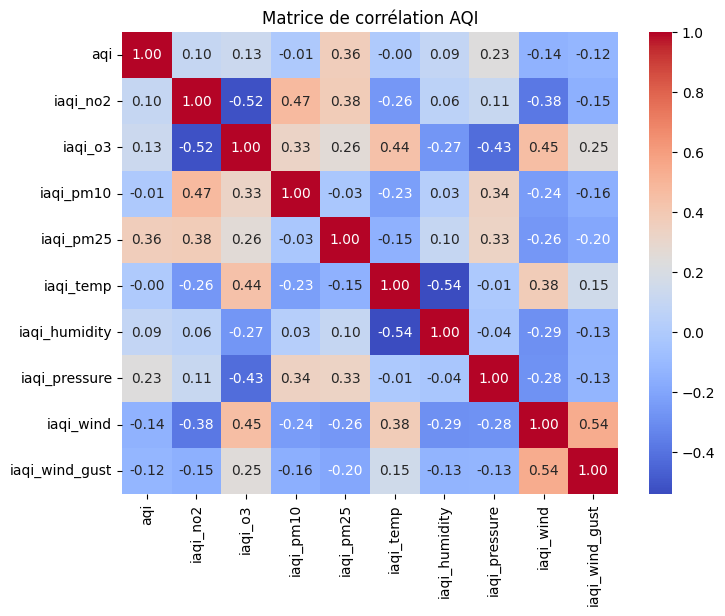

In [10]:


corr_matrix = df_corr.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation AQI")
plt.show()


In [11]:
df_model =  df[['aqi','iaqi_o3', 'iaqi_pm10','iaqi_pm25']]

In [16]:
# ============================================================
# 1. PRÉPARATION DES DONNÉES
# ============================================================

TARGET = "aqi"  # En majuscule pour correspondre à Snowflake

# Nettoyage des valeurs manquantes sur la cible
df_model = df_model.dropna(subset=[TARGET])

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================================
# 2. CONFIGURATION DES PIPELINES
# ============================================================

# Définition des modèles à tester
model_factory = {
    "LinearRegression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "DecisionTree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeRegressor(random_state=42))
    ]),
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(random_state=42, n_estimators=300))
    ]),
    "GradientBoosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(random_state=42))
    ]),
}

# ============================================================
# 3. ENTRAÎNEMENT ET ÉVALUATION
# ============================================================

performance_log = {}
trained_pipelines = {}

print(f"🚀 Début de l'entraînement sur {len(X_train)} lignes...")

for name, pipeline in model_factory.items():
    # Entraînement
    pipeline.fit(X_train, y_train)
    
    # Prédiction
    y_pred = pipeline.predict(X_test)
    
    # Métriques
    performance_log[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }
    trained_pipelines[name] = pipeline
    print(f"✅ {name} entraîné (R²: {performance_log[name]['R2']:.4f})")

# ============================================================
# 4. SÉLECTION ET SAUVEGARDE DU MEILLEUR MODÈLE
# ============================================================

# Choix du meilleur modèle basé sur le R²
best_model_name = max(performance_log, key=lambda k: performance_log[k]["R2"])
best_pipeline = trained_pipelines[best_model_name]

# Gestion du répertoire de stockage (Volume Airflow/Docker)
MODEL_DIR = "/app/models"
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_PATH = os.path.join(MODEL_DIR, "best_model_aqi.joblib")

# Sauvegarde physique
joblib.dump(best_pipeline, MODEL_PATH)

print(f"\n🏆 MEILLEUR MODÈLE : {best_model_name}")
print(f"💾 Sauvegardé sous : {MODEL_PATH}")

# ============================================================
# 5. EXPORT DES RÉSULTATS POUR SNOWFLAKE
# ============================================================

# Transformation du dictionnaire de scores en DataFrame
df_results = pd.DataFrame.from_dict(performance_log, orient='index').reset_index()
df_results.columns = ['MODEL_NAME', 'MAE', 'RMSE', 'R2']

# Ajout des métadonnées de tracking
df_results['TRAINING_DATE'] = datetime.now()
df_results['IS_BEST'] = df_results['MODEL_NAME'] == best_model_name

# Mise en forme pour Snowflake (Majuscules)
df_results.columns = [col.upper() for col in df_results.columns]

print("\n📊 Tableau de performance prêt pour Snowflake :")
print(df_results.to_string(index=False))

🚀 Début de l'entraînement sur 68077 lignes...
✅ LinearRegression entraîné (R²: 0.1338)
✅ DecisionTree entraîné (R²: 0.9323)
✅ RandomForest entraîné (R²: 0.9574)
✅ GradientBoosting entraîné (R²: 0.9405)

🏆 MEILLEUR MODÈLE : RandomForest
💾 Sauvegardé sous : /app/models\best_model_aqi.joblib

📊 Tableau de performance prêt pour Snowflake :
      MODEL_NAME       MAE      RMSE       R2              TRAINING_DATE  IS_BEST
LinearRegression 14.064861 18.781333 0.133764 2026-03-02 22:23:50.059749    False
    DecisionTree  0.876288  5.252455 0.932250 2026-03-02 22:23:50.059749    False
    RandomForest  0.841836  4.165165 0.957396 2026-03-02 22:23:50.059749     True
GradientBoosting  2.386662  4.924002 0.940458 2026-03-02 22:23:50.059749    False
